## 将04文档中的核心部分摘出来，得到最终模型

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold  

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv') 

In [6]:
df 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [8]:
type(df.dtypes)

pandas.Series

In [56]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [57]:
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ','_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [58]:
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [59]:
df_full_train,df_test = train_test_split(df, test_size=0.2, random_state=1)

In [60]:
len(df_full_train),len(df_test)

(5634, 1409)

In [61]:
df_train,df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [62]:
len(df_full_train),len(df_test),len(df_train),len(df_val)

(5634, 1409, 4225, 1409)

In [63]:
y_train = df_train.churn.values 
y_val = df_val.churn.values 
y_test = df_test.churn.values 

In [29]:
#del df_train['churn']
#del df_val['churn']
#del df_test['churn']

In [70]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents','phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling','paymentmethod']

In [71]:
numerical = ['tenure','monthlycharges','totalcharges']

In [72]:
def train(df_train, y_train,C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(C=C,solver='liblinear',max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [73]:
def predict(df_train, dv, model):
    dicts = df_train[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]
    return y_pred 

In [84]:
n_splits = 5
C = 1.0 
scores = []
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

In [85]:
for train_idx,val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val =  df_full_train.iloc[val_idx]
        y_train = df_train.churn.values
        y_val = df_val.churn.values
        
        dv,model = train(df_train, y_train ,C=C) 
        y_pred = predict(df_val,dv,model)
        auc =  roc_auc_score(y_val,y_pred)
        scores.append(auc)
print('%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

1.0 0.841 +- 0.007


In [88]:
scores

[0.8423240260300963,
 0.8453247086478611,
 0.8335059201284366,
 0.8323627454115241,
 0.8521736060995889]

In [89]:
dv,model = train(df_full_train, df_full_train.churn.values ,C=1) 
y_pred = predict(df_test,dv,model)
auc =  roc_auc_score(y_test,y_pred)
auc

0.8579400803839363

## 5.1 Intro / Session overview
What we will cover this week

### voerview --  **MLOps 模型部署与监控的全景图**
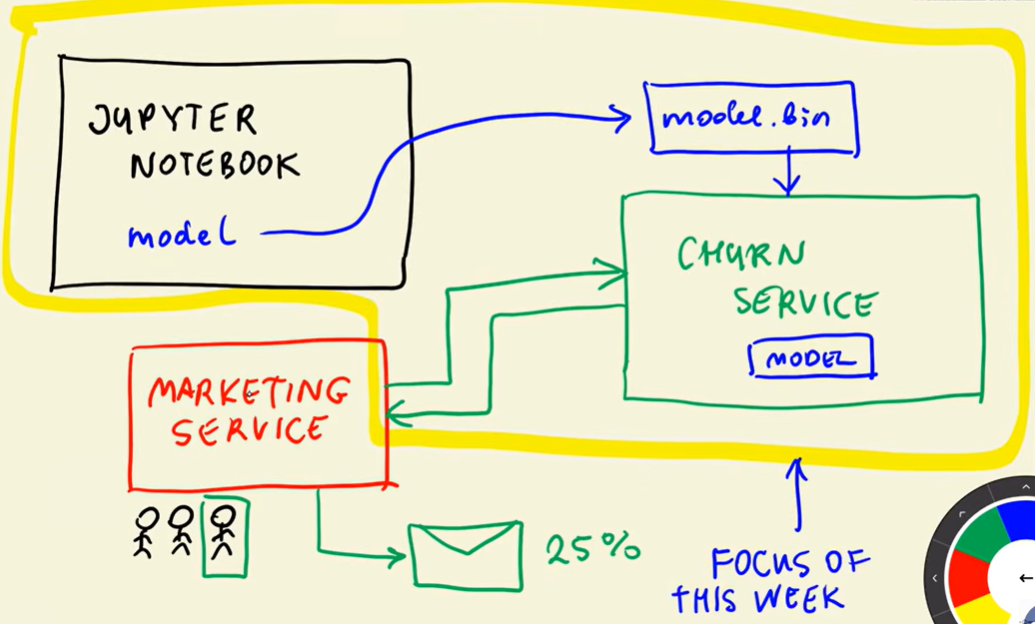


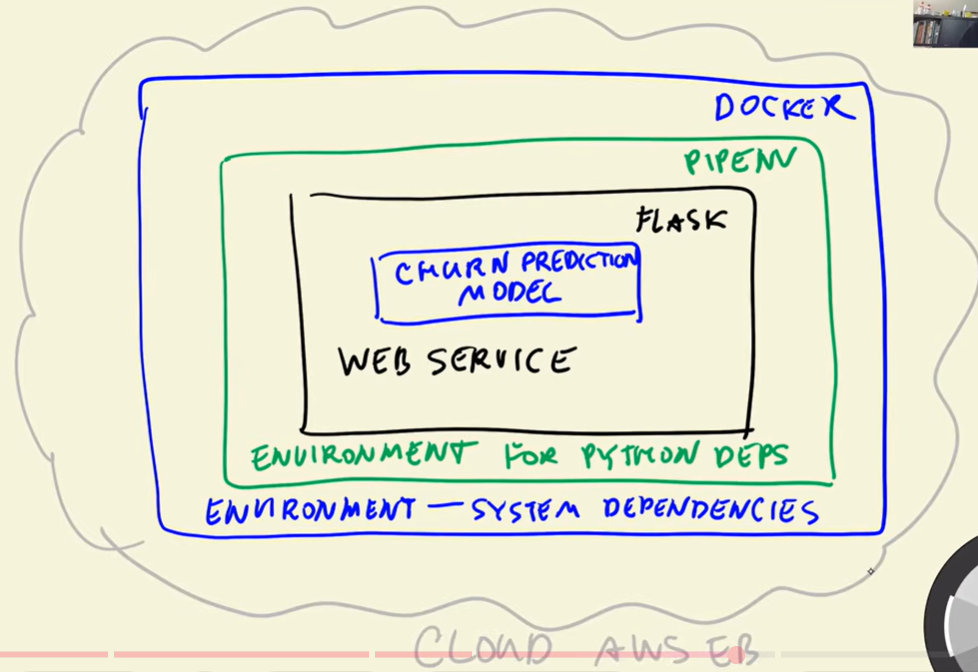


## 5.2 Saving and loading the model
- Saving the model to pickle
- Loading the model from pickle
- Turning our notebook into a Python script

### - Saving the model to pickle

In [90]:
import pickle  #  pickle  Python的“打包/拆包”工具，能将 Python 里的任何对象转换成“字节流”，并保存到文件中。

In [91]:
output_file = f'model_C={C}.bin'  #定义一个字符串变量 output_file，用来存放文件名。
output_file

'model_C=1.0.bin'

In [92]:
f_out = open(output_file,'wb')  #用 Python 内置的 open 函数打开一个文件,wb'：代表 Write Binary（以二进制模式写入）
pickle.dump((dv,model),f_out)  #模型数据就已经被写入到 f_out 指向的文件中了 
f_out.close()            # 关闭刚才打开的文件

In [93]:
# 上面的打开，写入数据，关闭文件，可以使用with语句实现
with open(output_file, 'wb') as f_out:
    pickle.dump((dv, model), f_out)

### 上面这部分代码，见脚本文件：training0.py

### - load the model to pickle

In [ ]:
import pickle 

In [99]:
model_file = 'model_C=1.0.bin'

In [100]:
# 读取文件内容
with open(model_file, 'rb') as f_in:
   dv, model =  pickle.load(f_in)

In [101]:
dv,model

(DictVectorizer(sparse=False),
 LogisticRegression(C=1, max_iter=1000, solver='liblinear'))

In [103]:
# 假设这个客户是新的用户信息
customer = {
'gender': 'female',
'seniorcitizen': 0,
'partner': 'yes',
'dependents': 'no',
'phoneservice': 'no',
'multiplelines': 'no_phone_service',
'internetservice': 'dsl',
'onlinesecurity':'no',
'onlinebackup': 'yes',
'deviceprotection':'no',
'techsupport':'no',
'streamingtv':'no',
'streamingmovies':'no',
'contract':'month-to-month',
'paperlessbilling': 'yes',
'paymentmethod':'electronic_check',
'tenure': 1,
'monthlycharges': 29.85,
'totalcharges': 29.85
}

In [106]:
# 先把这个用户数据做向量化
X = dv.transform([customer])

In [109]:
model.predict_proba(X)[:,1]

array([0.64330135])

In [112]:
# 将ipynb文件，转换为py后缀的脚本文件,会生成同名的py为后缀的文件，在同个目录中
!jupyter nbconvert --to script  07_deploying_machine_learning_models.ipynb

24544.01s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


[NbConvertApp] Converting notebook 07_deploying_machine_learning_models.ipynb to script
[NbConvertApp] Writing 6075 bytes to 07_deploying_machine_learning_models.py


### 上面这部分代码，见脚本文件：predicition0.py

## 5.3 Web services: introduction to Flask
- Writing a simple ping/pong app
- Querying it with 'curl' and browser

## 5.4 Serving the churn model with Flask
- Wrapping the predict script into a Flask app
- Querying it with 'requests'
- Preparing for production: gunicorn
- Running it on Windows with waitress

In [ ]:
pip list | grep flask  # 首先安装flask库

#### 检查安装结果：
输入： pip3 show flask
输出：Name: Flask
Version: 3.1.3
Summary: A simple framework for building complex web applications.
Home-page: 
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /root/miniconda3/envs/quant/lib/python3.11/site-packages
Requires: blinker, click, itsdangerous, jinja2, markupsafe, werkzeug
Required-by: 

In [ ]:
#### 创建ping脚本

from flask import Flask

app = Flask('ping')

@app.route('/ping',methods=['GET'])

def ping():

  return "PONG"

if __name__ == '__main__':
 
    app.run(debug=True, host='0.0.0.0', port=9696)

#### 测试ping的web服务
$ curl http://127.0.0.1:9696/ping
PONG

浏览器访问方式：
http://127.0.0.1:9696/ping


#### 创建了，web服务程序： predicition1.py  ， web服务测试程序：predict_test.py 
##### 其中：predicition0.py 中自带数据，可以直接运行，predicition1.py 采用web方式，需要启动后，使用predict_test.py 去测试
#### 请在model_deploying 目录中查看相关代码

## web生产环境部署
gunicorn 是一个用来部署和运行 Python Web 应用的生产级 HTTP 服务器
我们开发时用 app.run() 启动的服务器，它的设计目标是方便调试，而不是应对线上的大量访问。

单线程，性能弱：它一次只能处理一个请求。如果有多个用户同时访问，其他人就得排队等待，响应会非常慢。

不稳定：它缺乏必要的安全保护和进程管理机制，一个请求出错就可能导致整个服务挂掉，不适合在公网上直接运行。

 Gunicorn 解决了什么问题？
Gunicorn 是一个强健的“管家”，它把你的 Flask 应用包装起来，提供强大的生产级服务能力：

支持并发，处理量大：它采用“预分叉工作模型”（pre-fork worker model）。启动后，它会创建多个工作进程（Worker） 来监听和处理请求。这样就能同时应对大量用户，充分利用服务器的多核 CPU。workers 的数量一般可以参考 2 × CPU核心数 + 1 来设置。

稳定可靠，持续服务：Gunicorn 自带一个管理进程（Master），它会时刻监控工作进程。如果有进程意外崩溃，Master 会自动重启新的 Worker，确保服务不会中断。

兼容性强，配置灵活：它能很好地与 Flask, FastAPI, Django 等各种 WSGI 或 ASGI 应用配合。你既可以通过命令行参数快速启动，也可以编写一个 Python 配置文件（如 gunicorn.conf.py）来精细控制所有行为，方便维护和版本管理。

In [ ]:
pip install gunicorn # 安装

In [ ]:
gunicorn --bind 0.0.0.0:9696 prediction1:app #运行web服务

## 5.5 Dependency and environment management: Pipenv
- Why we need virtual environment
- Installing Pipenv
- Installing libraries with Pipenv
- Running things with Pipenv

### 这一节讲了，1：就是python的虚拟环境的构建，可以让每个环境中的库的配置独立化，不互相影响。

#### 我此刻之前的所有操作，均是在python的虚拟环境中，这个环境是conda创建的env环境，且有专门的yml文件来配置所需的库文件
#### 这些内容，我会在机器学习课程结束以后，补充到最前面。
#### 本节，作者又讲到了这个pipenv，就是那个通过 pip  install  pipenv 来安装了一个类似conda的虚拟环境和包管理工使用
#### 我依然选择了现在的环境，决定不使用pipenv来管理python虚拟环境和库，可能会造成混乱。

#### 记录一个小问题
#### (quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml# pip check
查到个兼容性问题，并且进行了修复，记录一下：
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml# pip check
torch 2.5.1 requires fsspec, which is not installed.
torch 2.5.1 has requirement sympy==1.13.1; python_version >= "3.9", but you have sympy 1.14.0.
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml# conda info --envs | grep '*'   # * -> active
quant                *   /root/miniconda3/envs/quant
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml# conda install -n quant pytorch=2.5.1 torchvision torchaudio pytorch-cuda=11.8 fsspec sympy=1.13.1 -c pytorch -c nvidia -c conda-forge --force-reinstall
2 channel Terms of Service accepted
Channels:
 - pytorch
 - nvidia
 - conda-forge
 - defaults
Platform: linux-64
Collecting package metadata (repodata.json): done
Solving environment: done


  environment location: /root/miniconda3/envs/quant

  added / updated specs:
    - fsspec
    - pytorch-cuda=11.8
    - pytorch=2.5.1
    - sympy=1.13.1
    - torchaudio
    - torchvision


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    fsspec-2026.7.0            |     pyhd8ed1ab_0         148 KB  conda-forge
    mpmath-1.3.0               |     pyhd8ed1ab_1         429 KB  conda-forge
    openssl-3.6.3              |       h35e630c_1         3.0 MB  conda-forge
    sympy-1.13.1               | pypyh2585a3b_103         4.4 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         8.1 MB

The following NEW packages will be INSTALLED:

  fsspec             conda-forge/noarch::fsspec-2026.7.0-pyhd8ed1ab_0 

The following packages will be UPDATED:

  ca-certificates    pkgs/main/linux-64::ca-certificates-2~ --> conda-forge/noarch::ca-certificates-2026.7.22-hbd8a1cb_0 
  openssl                                  3.6.2-h35e630c_0 --> 3.6.3-h35e630c_1 

The following packages will be DOWNGRADED:

  mpmath                                 1.4.1-pyhd8ed1ab_0 --> 1.3.0-pyhd8ed1ab_1 
  sympy                               1.14.0-pyh2585a3b_106 --> 1.13.1-pypyh2585a3b_103 


Proceed ([y]/n)? y


Downloading and Extracting Packages:
                                                                                                    
Preparing transaction: done                                                                         
Verifying transaction: done                                                                         
Executing transaction: done       


(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml# pip check
No broken requirements found.

#### 给conda增加配置，类似pipfile.lock的工具，用于记录确切的库信息
#### 安装
conda install conda-lock -c conda-forge
#### 基于 environment.yml 生成锁定文件
conda-lock -f environment.yml -p linux-64 
最终会在 environment.yml  所在的目录，生成conda-lock.yml文件
### 注意：***这一步不是必须的，可以忽略，不需要做***

### ***非常重要的问题***：
pip install pipenv  的安装，是为了给后面的docker相关工作，创建依赖包的配置信息，所以这一步我们必须做，做的方法如下：
1. 查看导入的模块
grep -E "^import |^from " prediction1.py

2. 查看所有包及其大小
conda list --export

pip list --format=freeze > all_packages.txt

3. 把第2步中的内容，发给AI，给AI描述清楚需求和现状，让其帮助你生成Pipfile文件内容，自己手动创建文件，复制内容进去，保存。放入项目目录。

我的如下：
[[source]]

url = "https://pypi.org/simple"

verify_ssl = true

name = "pypi"

[packages]

flask = "==3.1.3"

gunicorn = "==26.1.0"

numpy = "==2.4.4"

pandas = "==3.0.3"

scikit-learn = "==1.8.0"


[dev-packages]

[requires]
python_version = "3.11"


4. 生成 Pipfile.lock

- 安装 pipenv

pip install pipenv

- 生成 Pipfile.lock

pipenv lock


## 5.6 Environment management: Docker
- Why we need Docker
- Running a Python image with docker
- Dockerfile
- Building a docker image
- Running a docker image

### 注意：先要在linux开发环境，安装docker。自行安装，不再赘述。

In [ ]:
# 运行以下命令，从hub.docker.com 中下载镜像
docker pull python:3.11.16-slim-bookworm

In [ ]:
docker run -it --rm python:3.11.16-slim-bookworm   /bin/bash  # 进入容器
docker run -it --rm --entrypoint=bash python:3.11.16-slim-bookworm   # 进入容器的第2种方法
docker run -it --rm  python:3.11.16-slim-bookworm             # 打开容器的python解释器
# 注意，以上命令，都会在退出容器后，容器被自动删除

In [ ]:
# 这两个命令，先留着，先不要执行
apt-get update
apt-get install wget

In [ ]:
构建dockfile文件，用于创建docker镜像
# 指定基础镜像
# 使用 Python 3.11.16 的 slim 版本（精简版，基于 Debian Bookworm）
FROM python:3.11.16-slim-bookworm
# 在镜像中安装 pipenv（Python 依赖管理工具）
# pipenv 用于根据 Pipfile 和 Pipfile.lock 安装依赖
RUN pip install pipenv -i https://pypi.tuna.tsinghua.edu.cn/simple
# 设置工作目录为 /app
# 后续的 COPY、RUN 等命令都在这个目录下执行
# 如果目录不存在，会自动创建
WORKDIR /app
# 从宿主机复制 Pipfile 和 Pipfile.lock 到镜像的 /app 目录
# [ ] 表示列表格式，可以一次复制多个文件
# "./" 表示当前工作目录（即 /app）
COPY ["Pipfile", "Pipfile.lock", "./"]
# 运行 pipenv install 安装所有依赖
# --system: 安装到系统的 Python 环境，而不是虚拟环境
# --deploy: 严格模式，要求 Pipfile.lock 存在且与 Pipfile 匹配
#           如果版本不匹配，构建会失败（保证可重现）
RUN pipenv install --system --deploy  -i https://pypi.tuna.tsinghua.edu.cn/simple
# 复制业务代码和模型文件到镜像
# prediction1.py: Flask 应用代码
# model_C=1.0.bin: 训练好的机器学习模型文件
COPY ["prediction1.py", "model_C=1.0.bin", "./"]
# 声明容器运行时监听的端口号
# 这只是文档说明，不会实际打开端口
# 真正的端口映射需要在 docker run 时用 -p 参数
EXPOSE 9696
# 设置容器的入口命令
# 容器启动时自动执行 gunicorn，绑定 0.0.0.0:9696
# prediction1:app 表示 prediction1.py 文件中的 app 对象（Flask 实例）
# 这个命令会覆盖 Dockerfile 中的 CMD，但不会被 docker run 的命令行参数覆盖
ENTRYPOINT ["gunicorn", "--bind=0.0.0.0:9696", "prediction1:app"]


In [ ]:
# 创建镜像，注意，Pipfile ，Pipfile.lock dockfile ，还有要打包的程序，都必须在一个目录中，且在该目录中执行这条命令
docker build -t ml-prediction:latest .

In [ ]:
# 用新创建的镜像，启动容器
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/model_deploying# docker images
                                                       i Info →   U  In Use
IMAGE                      ID             DISK USAGE   CONTENT SIZE   EXTRA
ml-prediction:latest       8c52fda9caca        897MB          252MB        
python:3.11.16-slim-bookworm
                           2e32f7d302ad        199MB         50.4MB        
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/model_deploying# docker  run -it --rm  -p 9696:9696 ml-prediction:latest

In [ ]:
# 在终端中测试
(base) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/model_deploying# python predict_test.py 
{'churn': False, 'probability': 0.3518037349799026}
not sending promo email to xyz-123

## 5.7 Deployment to the cloud: AWS Elastic Beanstalk (optional)
- Installing the eb cli
- Running eb locally
- Deploying the model

### aws的服务，注册需要自己有银联信用卡
### 以下我将分别记录alexey老师的授课内容，及我的时间内容

### 一、alexey老师的授课内容

In [ ]:
# 1. 远端的环境，可以通过ssh，远程登陆上去

In [ ]:
# 2. Elastic Beanstalk 提供模型的负载均衡服务，

训练好的模型就像一个AI专家。当用户请求很少时（比如一天就10个人问），这一个专家（一个容器）完全能应付。但当用户请求暴增（比如1秒钟有1000个人同时问），这个专家就算不眠不休也处理不过来。

负载均衡要解决的就是这个问题：

复制专家：把你的模型镜像（这个AI专家）复制多份，在服务器上启动多个完全一样的容器（比如3个、10个甚至100个）。

安排接待员：在所有这些容器前面，部署一个负载均衡器（接待员）。

分发请求：当用户请求到达时，负载均衡器会按照一定的策略（比如轮询、最少连接数等），把请求分发给其中一个空闲的容器去处理。

In [ ]:
# 3. 针对第2点的描述，需要在本地环境中，做如下配置
#  - 配置：awsebcli 
pipenv install awsebcli  --dev

# 注意：该条命令，会创建虚拟环境，且虚拟环境的目录会指定为执行该命令的目录
# 查看pipenv的虚拟环境配置信息的命令是：pipenv --venv

#  -- 安装完成后，进入虚拟环境，初始化eb工具
pipenv  shell   # 一定要在上一条命令执行的目录中执行，也就是pipenv创建的虚拟环境的目录中执行
which eb  #确认eb情况

# 接下来是配置AWS上的IAM用户信息，需要自行注册AWS根用户，需要提供信用卡绑定，才能注册，注册地址：https://signin.aws.amazon.com 
# IAM用户配置教程：
https://blog.csdn.net/2401_84350246/article/details/150641402  
# 下面eb  init  -p  docker -r eu-west-1 churn-serving操作中，涉及到注册信息需要填写，创建访问密钥，在AWS上生成
https://blog.csdn.net/weixin_45428910/article/details/162086762

##注意：eb初始化中，涉及到创建密钥对的操作，可以创建。
如果已经在AWS的EC2服务中，手动创建了密钥对，并得到了私钥，要妥善保管私钥
将EC2生成私钥文件，导入到  /root/.ssh/ 这个目录中，去掉pem这个后缀名称，
chmod  600 /root/.ssh/私钥文件     要修改文件权限
- 这个私钥用来访问EC2环境的身份认证，要妥善保管好。

## 执行命令： eb  init  -p  docker -r ap-southeast-1 churn-serving
### -p 是 --platform 的缩写。 docker 指定了平台类型，告诉 Elastic Beanstalk：我的应用是一个 Docker 容器。
### -r ap-southeast-1   
### -r 是 --region 的缩写。
### ap-southeast-1 指定了 AWS 区域代码。ap-southeast-1 指的是新加坡区域。AWS 在全球有很多数据中心，你需要明确告诉 EB CLI，把你的应用部署到哪个区域。你可以选择离你的用户更近的、或者你有权限的区域。
### churn-serving   这是应用名称。

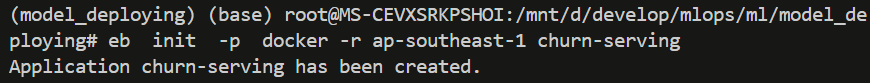

 创建成功后，ls -a 就可以看到 .elasticbeanstalk 的目录，里面有个config.yml配置文件，类似下面的配置内容

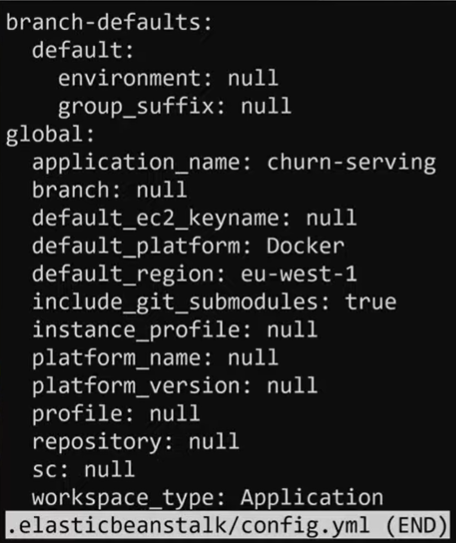

##  --继续在本地做测试：这是部署前模拟。目的是在本地完整复现 Elastic Beanstalk（EB）在云端将如何构建、打包和运行你的应用。它的重点不是“运行代码”，而是“运行 EB 的部署流程”。
eb local run  --port 9696
条命令会读取你项目目录中的 Docker 配置文件（如 Dockerfile），
并自动执行 docker build 来构建镜像，然后基于这个镜像运行容器
如图：镜像创建完成，容器启动，容器正常，紧接着的这个测试执行完成后，被我ctrl + c 退出了。
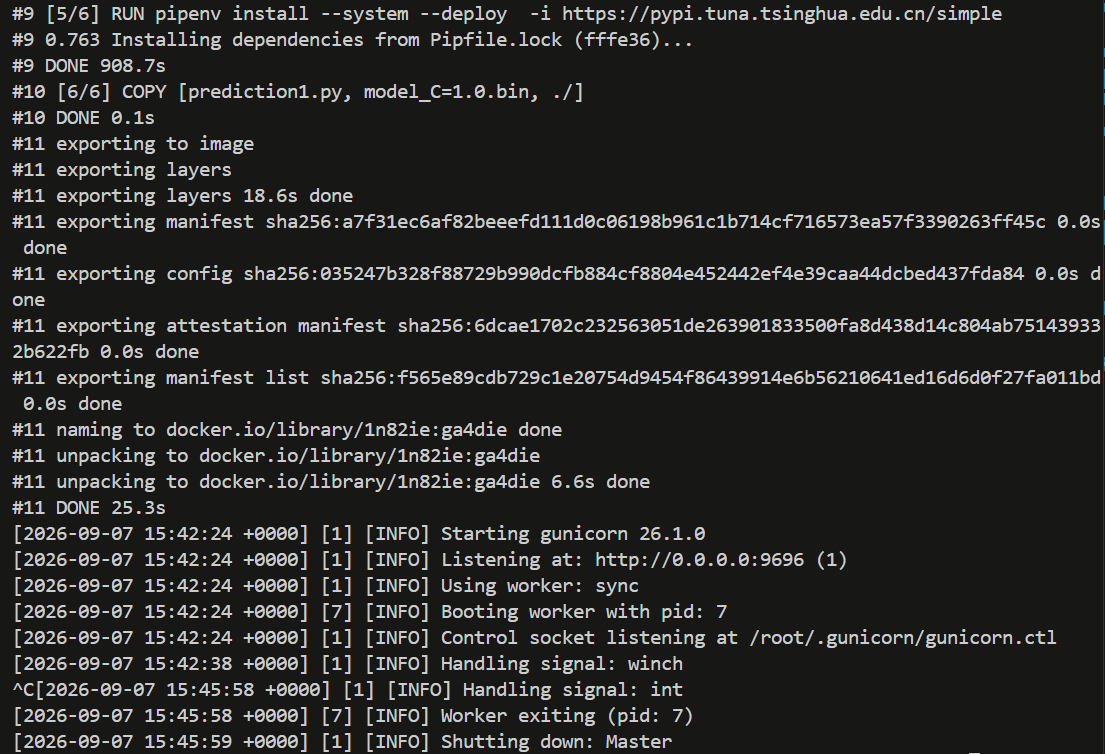

# --在本地，使用predict_test.py  测试上一步中所创建的容器
python  predict_test.py
如下图：第一个镜像，就是刚刚生成的镜像，容器就1个，对应这个镜像。
执行了测试脚本，输出了测试结果。
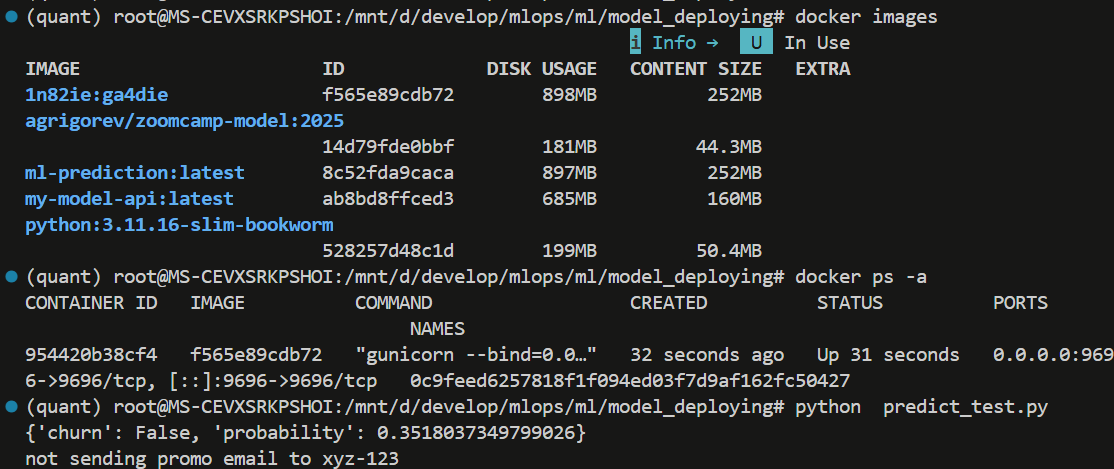

In [ ]:
# 将镜像放到云端运行。
eb create churn-serving-env
# churn-serving-env  就是在eb上创建的环境的名称
如下图：


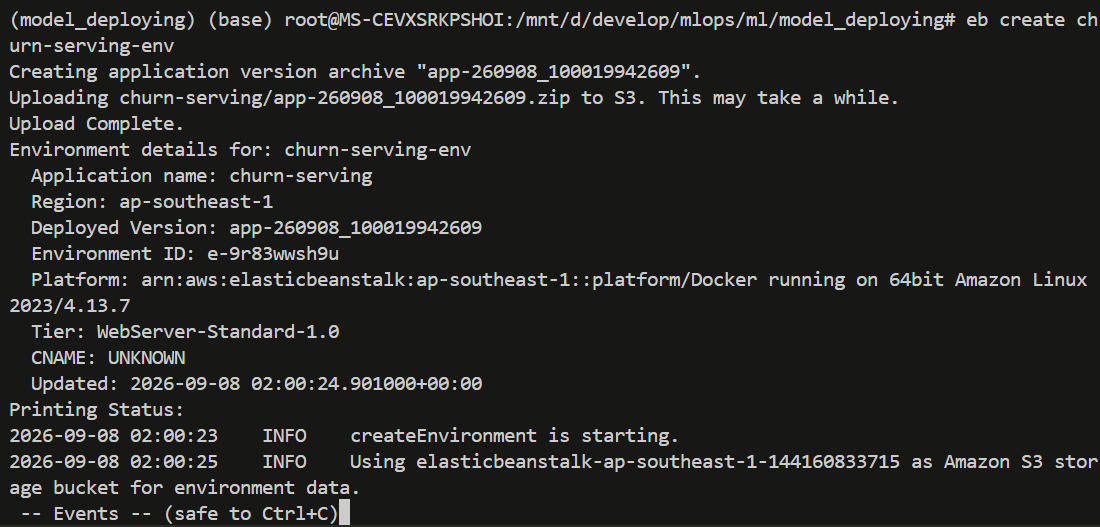
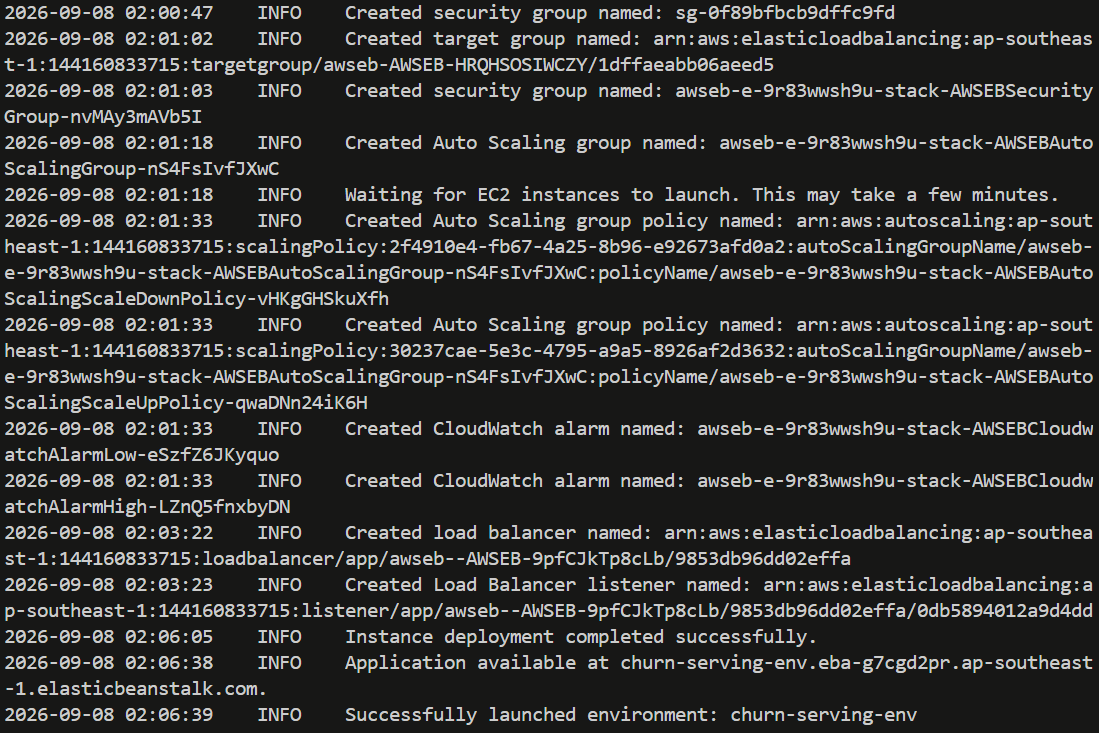

In [ ]:
最后一张图，会在倒数第二行，生成服务的网络地址，复制下来

In [ ]:
编辑本地的predict_test.py 文件
host = 'churn-serving-env.eba-g7cgd2pr.ap-southeast-1.elasticbeanstalk.com'
url = f'http://{host}/predict'

In [ ]:
churn-serving-env.eba-g7cgd2pr.ap-southeast-1.elasticbeanstalk.com
这就是aws云端，面向所有个人都开放的1个机器学习的人员流失预测模型服务。

In [ ]:
# 终止模型的对外服务 ， 终止（删除）旧环境
# 如果部署失败，也使用该命令，先删除失败的部署内容
eb terminate churn-serving-env

可以远程到EC2虚拟化环境，还可以再进入docker容器内部
eb  ssh  

## 5.8 Explore more
- Flask is not the only framework for creating web services. Try others,e.g. FastAPI
- Experiment with other ways of managing environment, e.g. virtual env,conda, poetry.
- Explore other ways of deploying web services, e.g. GCP, Azure, Heroku,Python Anywhere, etc